# val_04 — Flagging sessions where the lickometer misses licks

This notebook responds to
[dynamic-foraging-processing#96](https://github.com/AllenNeuralDynamics/dynamic-foraging-processing/issues/96),
which reports licks that are visible in the video but never registered by the lickometer. It
measures how often that happens and proposes two QC metrics.

A bottom-view camera tracks `tongue_tip_center` with Lightning Pose. A pose lick is a frame where
the tongue tip comes within `d` pixels of a spout, with a 0.1 s refractory period. If a lickometer
event falls within 100 ms of a pose lick, the two are matched; if none does, the pose lick is
pose-only.

Events are scored with the pose lick as the actual condition and the lickometer as the prediction,
using the terminology of the confusion matrix in
[Precision and recall](https://en.wikipedia.org/wiki/Precision_and_recall#Definition).

|                                    | Lickometer fired (predicted positive) | No lickometer event (predicted negative) |
| ---------------------------------- | ------------------------------------- | ---------------------------------------- |
| **Pose lick (actual positive)**    | true positive (TP) — matched          | false negative (FN) — pose-only          |
| **No pose lick (actual negative)** | false positive (FP) — lickometer-only | true negative (TN) — not counted         |

Matching events in pairs leaves the true negative cell undefined, so only TP, FN and FP are
counted. Writing P = TP + FN for the number of pose licks at a given `d`:

```
miss rate (FNR)  = FN / P          = of all pose licks, how many did the lickometer miss?
recall (TPR)     = TP / P          = of all pose licks, how many did the lickometer hit?
precision (PPV)  = TP / (TP + FP)  = of all lickometer licks, how many were detected by pose tracking?
```

Section 3 onward reports the miss rate, the fraction of pose licks for which the lickometer
recorded nothing.

A false negative can mean three things: **the lickometer failed to register a real lick (goal of QC)**, the tongue
approached a spout without touching it, or the keypoint was wrong. The timing of the event on its
own doesn't say which. §5 lists the limitations this creates.

The dataset is 53 sessions from 17 subjects, recorded between 2024-05-31 and 2025-07-03. The
session named in issue #96, `behavior_856239_2026-07-24_12-50-23`, has no pose output yet, so it isn't
included.

1. Setup
2. Tongue-to-spout distance when the lickometer fires
3. Miss rate across sessions
4. Day-to-day range within an animal
5. Limitations
6. Two QC metrics
7. Example missed licks
8. Confidence threshold

## 1. Setup

In [7]:
%matplotlib inline
from pathlib import Path
import glob
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_kinematics_utils import (
    mask_keypoint_data,
)
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_lickometer_utils import (
    detect_licks,
    filter_timestamps_refractory,
    calculate_metrics_witheventkeys,
    extract_clips_ffmpeg_encode,
)
from aind_dynamic_foraging_behavior_video_analysis.kinematics.video_clip_utils import (
    get_video_time,
    find_labeled_video,
)
from aind_dynamic_foraging_behavior_video_analysis.video_alignment import (
    session_time_to_video_time,
)
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import find_session_dir

from plotstyle import apply_style, PALETTE, style_ax, save_fig
apply_style()

In [8]:
if Path("/root/capsule").exists():
    ENV     = "codeocean"
    SCRATCH = Path("/root/capsule/scratch")
    DATA    = Path("/root/capsule/data")
else:
    ENV     = "local"
    SCRATCH = Path("/Users/mib/Documents/Code/kinematics_analysis/data")
    DATA    = SCRATCH

IS_CO    = ENV == "codeocean"
FIG_DIR  = SCRATCH / "figures" / "val_04_lickometer_qc"
SAVE_FIG = False

SESSION_DIR     = SCRATCH / "session_analysis_mlk"
EXAMPLE_SESSION = "behavior_716325_2024-05-31_10-31-14"

# Detection parameters.
CONF          = 0.8    # keypoint confidence floor for masking
T_REFRACTORY  = 0.1    # s; suppresses re-detection from jitter around the threshold
MATCH_WINDOW  = 0.1    # s; pose and lickometer events this close are the same lick
LICK_HALFWIN  = 0.1    # s; half-width for measuring distance around a lickometer lick

# D0 is the distance used for every session-level number below. 10 px is 2.7x the
# tongue_tip_center error of 3.67 px (pixel_error.ipynb), close enough that a pose lick
# means the tongue reached the spout. SWEEP is only used for the calibration curve.
D0    = 10
SWEEP = [10, 15, 20, 25, 30, 40]

# QC gates and flags, used in S6.
MIN_N_POSE         = 300    # qualifying events needed before a session is ranked
MIN_LICK_COVERAGE  = 0.90   # fraction of lickometer licks with a tracked tongue nearby
FLAG_MISS          = 0.10   # flag a session when the Wilson lower bound clears this
FLAG_SPREAD        = 0.10   # flag a subject when its day-to-day range clears this

C_POSE    = PALETTE["pos"]       # pose-only / flagged
C_LICKO   = PALETTE["neg"]       # lickometer
C_NEUTRAL = PALETTE["not_sig"]   # unflagged

print("ENV={}".format(ENV))

ENV=codeocean


In [9]:
def load_session(inter, conf=None):
    """Load one session's tongue keypoints, spout positions and lickometer licks.

    Parameters
    ----------
    inter : pathlib.Path
        The session's ``intermediate_data`` directory.
    conf : float, optional
        Keypoint confidence floor for masking. Defaults to ``CONF``.

    Returns
    -------
    dict
        ``tongue`` (masked keypoint table on session time, with ``spout_distance``),
        ``spoutL``/``spoutR`` (mean positions, de-mirrored), ``licks`` (lickometer
        times, session time) and ``video_offset`` (seconds to add to session time to
        get video time).
    """
    keypoint_dfs = {
        key: pd.read_parquet(inter / "kps_raw_{}.parquet".format(key))
        for key in ["tongue_tip_center", "spout_l", "spout_r"]
    }
    kins = pd.read_parquet(inter / "tongue_kins.parquet",
                           columns=["time", "time_in_session"])

    conf = CONF if conf is None else conf
    tongue = mask_keypoint_data(keypoint_dfs, "tongue_tip_center", confidence_threshold=conf)
    tongue["time"] = kins["time_in_session"].values

    # NB the bottom camera mirrors left/right, so spout_r holds the left spout.
    spoutL = np.mean(keypoint_dfs["spout_r"][["x", "y"]], 0)
    spoutR = np.mean(keypoint_dfs["spout_l"][["x", "y"]], 0)

    # Distance to the nearer spout, per frame. Untracked frames stay NaN.
    tracked = tongue[["x", "y"]].notna().all(axis=1)
    xy = tongue.loc[tracked, ["x", "y"]].to_numpy()
    dL = np.linalg.norm(xy - np.array([spoutL["x"], spoutL["y"]]), axis=1)
    dR = np.linalg.norm(xy - np.array([spoutR["x"], spoutR["y"]]), axis=1)
    tongue["spout_distance"] = np.nan
    tongue.loc[tracked, "spout_distance"] = np.minimum(dL, dR)

    return {
        "tongue": tongue, "spoutL": spoutL, "spoutR": spoutR,
        "licks": np.sort(
            pd.read_parquet(inter / "nwb_df_licks.parquet")["timestamps"].to_numpy()),
        # kps_raw_* `time` is video-relative and tongue_kins carries both bases, so
        # get_video_time at 0 returns the session -> video offset itself.
        "video_offset": float(get_video_time(0.0, kins)),
    }


def min_distance_near(times, dist, event_times, halfwidth):
    """Minimum tracked tongue-spout distance within +/- halfwidth of each event.

    Parameters
    ----------
    times, dist : ndarray
        Tracked frames only, sorted by time, no NaN.
    event_times : ndarray
        Times to measure around, in the same base as ``times``.
    halfwidth : float
        Half-width of the search window, in seconds.

    Returns
    -------
    ndarray
        One value per event; NaN where no tracked frame falls in the window.
    """
    event_times = np.asarray(event_times, dtype=float)
    lo = np.searchsorted(times, event_times - halfwidth, side="left")
    hi = np.searchsorted(times, event_times + halfwidth, side="right")
    out = np.full(event_times.size, np.nan)
    for k in range(event_times.size):
        if hi[k] > lo[k]:
            out[k] = dist[lo[k]:hi[k]].min()
    return out

In [10]:
def classify_events(sess, d):
    """Detect pose licks at distance ``d`` and score them against the lickometer.

    Parameters
    ----------
    sess : dict
        Output of :func:`load_session`.
    d : float
        Tongue-to-spout distance that counts as a pose lick, in pixels.

    Returns
    -------
    dict
        Counts ``n_matched`` (TP), ``n_pose_only`` (FN), ``n_lickometer_only`` (FP)
        and ``n_pose`` (P = TP + FN); ``miss_rate`` (FNR = FN / P), ``recall``
        (TPR = TP / P), ``precision`` (PPV = TP / (TP + FP)); ``pose_only_times``; and
        the refractory-filtered lists that were classified, ``pose_lick_times`` and
        ``lickometer_times``.
    """
    pose_licks = detect_licks(sess["tongue"], sess["spoutL"], sess["spoutR"], d)
    pose_licks = filter_timestamps_refractory(pose_licks, T_REFRACTORY)
    licko_licks = filter_timestamps_refractory(list(sess["licks"]), T_REFRACTORY)

    # The library signature is (ground_truth, detected_events) -> (tp, fp, fn, gt_df, det_df),
    # so passing pose first makes the pose lick the actual condition and the lickometer the
    # prediction. Unmatched pose events come back tagged "False Negative" in pose_tbl.
    n_matched, n_lickometer_only, n_pose_only, pose_tbl, _ = (
        calculate_metrics_witheventkeys(pose_licks, licko_licks, time_window=MATCH_WINDOW))

    n_pose = n_matched + n_pose_only          # P = TP + FN, the pose licks
    n_licko = n_matched + n_lickometer_only   # TP + FP, the lickometer events
    return {
        "d": d, "n_matched": n_matched, "n_pose_only": n_pose_only,
        "n_lickometer_only": n_lickometer_only, "n_pose": n_pose,
        "miss_rate": n_pose_only / n_pose if n_pose > 0 else np.nan,      # FNR = FN / P
        "recall": n_matched / n_pose if n_pose > 0 else np.nan,           # TPR = TP / P
        "precision": n_matched / n_licko if n_licko > 0 else np.nan,      # PPV = TP / (TP + FP)
        "pose_only_times": pose_tbl.loc[
            pose_tbl["Status"] == "False Negative", "Time"].to_numpy(),
        # The event lists as classified, after the refractory filter. detect_licks already
        # returns one timestamp per run below d, and the filter drops any that follow the
        # previous one by less than T_REFRACTORY.
        "pose_lick_times": np.asarray(pose_licks, dtype=float),
        "lickometer_times": np.asarray(licko_licks, dtype=float),
    }


def wilson_ci(k, n, z=1.96):
    """Wilson score interval for k successes in n trials. NaN pair when n is 0."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return centre - half, centre + half

## 2. Tongue-to-spout distance when the lickometer fires

Choosing a value for `d` means knowing how far the tongue tip usually is from the spout at moments
when a lick definitely happened. This section measures that on one session,
`behavior_716325_2024-05-31_10-31-14`. Only confidence-filtered frames are used, and windows
containing no frame above confidence 0.8 are dropped.

The output then fills in the §1 confusion matrix with the counts at `D0`, reports the three metrics
from §1, and sweeps them over `d`.

In [11]:
if not IS_CO:
    print("[skip] Code Ocean only: needs session_analysis_mlk/<session>/intermediate_data/.")
else:
    inter = find_session_dir(EXAMPLE_SESSION, roots=[SESSION_DIR]) / "intermediate_data"
    with contextlib.redirect_stdout(io.StringIO()):
        S = load_session(inter)
    tongue, licks = S["tongue"], S["licks"]
    duration = float(tongue["time"].max() - tongue["time"].min())

    # Distance at each lickometer lick, and at uniformly drawn times for comparison.
    trk = tongue.loc[tongue["spout_distance"].notna(), ["time", "spout_distance"]]
    trk_t, trk_d = trk["time"].to_numpy(), trk["spout_distance"].to_numpy()
    d_at_lick = min_distance_near(trk_t, trk_d, licks, LICK_HALFWIN)
    rng = np.random.default_rng(0)
    d_at_random = min_distance_near(
        trk_t, trk_d,
        rng.uniform(tongue["time"].min(), tongue["time"].max(), len(licks)), LICK_HALFWIN)

    # D0 is included so the confusion matrix below can be read off the sweep.
    sweep_d = sorted(set(SWEEP) | {D0})
    with contextlib.redirect_stdout(io.StringIO()):
        example_sweep = pd.DataFrame([
            {k: v for k, v in classify_events(S, d).items() if k != "pose_only_times"}
            for d in sweep_d])

    print("Session:          {}".format(EXAMPLE_SESSION))
    print("Frames:           {:,} over {:.0f} s, tracked at conf >= {}: {:.0%}".format(
        len(tongue), duration, CONF, tongue["x"].notna().mean()))
    print("Lickometer licks: {:,} ({:.2f}/s)".format(len(licks), len(licks) / duration))
    print("\nDistance at lickometer licks (px): " + " | ".join(
        "{}th {:.1f}".format(q, np.nanpercentile(d_at_lick, q)) for q in [10, 25, 50, 75, 90]))
    print("Lick windows with no tracked frame:   {:,} / {:,} ({:.1%})".format(
        int(np.isnan(d_at_lick).sum()), len(d_at_lick), np.isnan(d_at_lick).mean()))
    print("Random windows with no tracked frame: {:,} / {:,} ({:.1%})".format(
        int(np.isnan(d_at_random).sum()), len(d_at_random), np.isnan(d_at_random).mean()))

    # The §1 confusion matrix, filled in at D0. Same layout, same cell names.
    r0 = example_sweep.loc[example_sweep["d"] == D0].iloc[0]
    tp, fn, fp = int(r0["n_matched"]), int(r0["n_pose_only"]), int(r0["n_lickometer_only"])
    events = pd.DataFrame(
        [["TP  {:,}".format(tp), "FN  {:,}".format(fn)],
         ["FP  {:,}".format(fp), "TN  not counted"]],
        index=["Pose lick (actual positive)", "No pose lick (actual negative)"],
        columns=["Lickometer fired (predicted positive)",
                 "No lickometer event (predicted negative)"])
    print("\nEvents at d = {} px:".format(D0))
    display(events)

    print("miss rate (FNR)  FN / P          = {:>5,} / {:>5,} = {:.4f}".format(
        fn, tp + fn, r0["miss_rate"]))
    print("recall    (TPR)  TP / P          = {:>5,} / {:>5,} = {:.4f}".format(
        tp, tp + fn, r0["recall"]))
    print("precision (PPV)  TP / (TP + FP)  = {:>5,} / {:>5,} = {:.4f}".format(
        tp, tp + fp, r0["precision"]))

    print("\nSwept over d:")
    display(example_sweep[["d", "miss_rate", "recall", "precision"]].round(4))

Session:          behavior_716325_2024-05-31_10-31-14
Frames:           2,689,718 over 5379 s, tracked at conf >= 0.8: 12%
Lickometer licks: 5,846 (1.09/s)

Distance at lickometer licks (px): 10th 3.7 | 25th 7.0 | 50th 11.0 | 75th 20.4 | 90th 29.9
Lick windows with no tracked frame:   1 / 5,846 (0.0%)
Random windows with no tracked frame: 4,068 / 5,846 (69.6%)

Events at d = 10 px:


,Lickometer fired (predicted positive),No lickometer event (predicted negative)
Pose lick (actual positive),"TP 2,617",FN 24
No pose lick (actual negative),"FP 3,225",TN not counted


miss rate (FNR)  FN / P          =    24 / 2,641 = 0.0091
recall    (TPR)  TP / P          = 2,617 / 2,641 = 0.9909
precision (PPV)  TP / (TP + FP)  = 2,617 / 5,842 = 0.4480

Swept over d:


,d,miss_rate,recall,precision
0,10,0.0091,0.9909,0.4480
1,15,0.0155,0.9845,0.6321
2,20,0.0215,0.9785,0.7417
3,25,0.0253,0.9747,0.8249
4,30,0.0363,0.9637,0.9009
5,40,0.0860,0.9140,0.9454


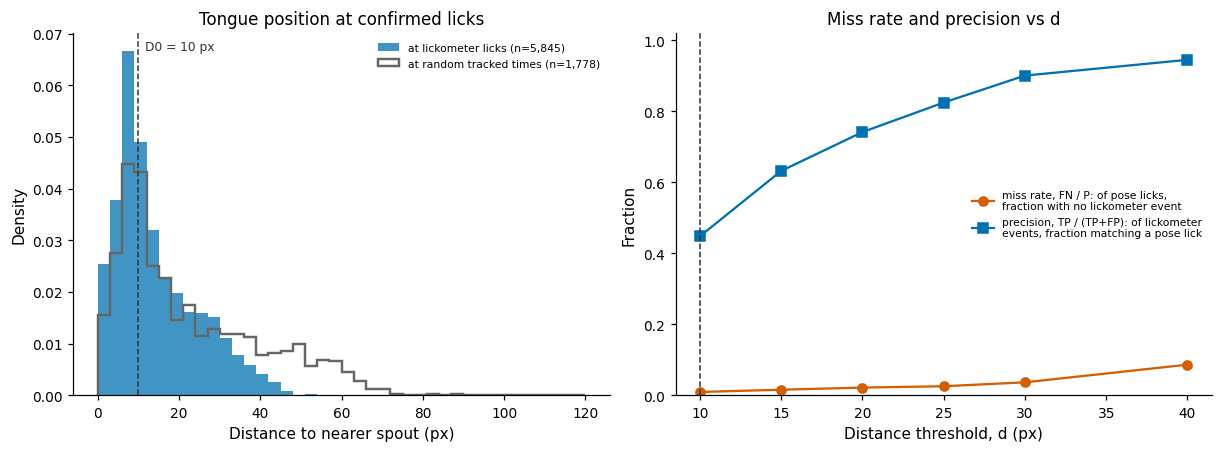

In [12]:
if not IS_CO:
    print("[skip] Figure 1 needs the example session.")
else:
    fig, axs = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")

    # -- panel 1: where the tongue is when the lickometer fires --
    # Plotted as densities: the two samples differ in n after dropping empty windows.
    bins = np.arange(0, 121, 3)
    axs[0].hist(d_at_lick[~np.isnan(d_at_lick)], bins=bins, density=True, color=C_LICKO,
                alpha=0.75, label="at lickometer licks (n={:,})".format(
                    int((~np.isnan(d_at_lick)).sum())))
    axs[0].hist(d_at_random[~np.isnan(d_at_random)], bins=bins, density=True, histtype="step",
                lw=1.6, color=PALETTE["neutral"], label="at random tracked times (n={:,})".format(
                    int((~np.isnan(d_at_random)).sum())))
    axs[0].axvline(D0, color=PALETTE["all"], ls="--", lw=1)
    axs[0].annotate("D0 = {} px".format(D0), xy=(D0, 1.0), xycoords=("data", "axes fraction"),
                    xytext=(4, -11), textcoords="offset points", fontsize=8,
                    color=PALETTE["all"])
    axs[0].set_xlabel("Distance to nearer spout (px)")
    axs[0].set_ylabel("Density")
    axs[0].set_title("Tongue position at confirmed licks")
    axs[0].legend(fontsize=7, loc="upper right")

    # -- panel 2: miss rate and precision as d changes --
    axs[1].plot(example_sweep["d"], example_sweep["miss_rate"], "o-", color=C_POSE,
                label="miss rate, FN / P: of pose licks,\nfraction with no lickometer event")
    axs[1].plot(example_sweep["d"], example_sweep["precision"], "s-", color=C_LICKO,
                label="precision, TP / (TP+FP): of lickometer\nevents, fraction matching a pose lick")
    axs[1].axvline(D0, color=PALETTE["all"], ls="--", lw=1)
    axs[1].set_ylim(0, 1.02)
    axs[1].set_xlabel("Distance threshold, d (px)")
    axs[1].set_ylabel("Fraction")
    axs[1].set_title("Miss rate and precision vs d")
    axs[1].legend(fontsize=7, loc="center right")

    for ax in axs:
        style_ax(ax)
    save_fig(fig, "fig1_calibration", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

### Reading the output

At a confirmed lick the tongue tip is a median of 11.0 px from the spout, and 90% of licks are
within 29.9 px.

Only 1 of the 5,846 lick windows contained no tracked frame, compared with 69.6% of windows placed
at random times, so the tongue is almost always tracked at the moment the lickometer fires.

`d` sets how strict the actual condition is. At 10 px the miss rate is 0.9%, recall is 0.99, 
and precision is 0.45; at 30 px they are 3.6%, 0.96 and 0.90. 

A tight `d` counts only close contacts as pose licks, which the lickometer nearly always registers, 
and it leaves most lickometer events with no matching pose lick. 

A loose `d` counts approaches that never made contact as pose licks, and the lickometer does not fire for
those, so they are counted as misses. 

The rest of the notebook uses `D0` = 10 px, where the 2,641 pose licks are somewhat under half of the 5,846 lickometer events.

## 3. Miss rate across sessions

The same measurement across all 53 sessions, with a 95% confidence interval on each. Two other numbers
come out of the same loop and are used as gates in §6.

- `lick_coverage` is the fraction of the lickometer's events that have a tracked tongue within
  ±100 ms. Where it is low, pose was not tracking well enough to establish the actual condition.
- `n_pose` is the number of qualifying events at `D0`. It ranges from 145 to 3,928 across the set,
  and below `MIN_N_POSE` the confidence interval is wider than the differences between sessions.

In [13]:
def session_miss_rate(sdir, thresholds=None):
    """Miss rate curve for one session. None when the intermediates are incomplete.

    Parameters
    ----------
    sdir : str or pathlib.Path
        A session directory under ``SESSION_DIR``.
    thresholds : list of float, optional
        Distances to evaluate. Defaults to ``SWEEP``.

    Returns
    -------
    pandas.DataFrame or None
        One row per threshold, with counts, miss rate, Wilson bounds and the
        session-level covariates.
    """
    thresholds = SWEEP if thresholds is None else thresholds
    inter = Path(sdir) / "intermediate_data"
    needed = ["kps_raw_tongue_tip_center.parquet", "kps_raw_spout_l.parquet",
              "kps_raw_spout_r.parquet", "tongue_kins.parquet", "nwb_df_licks.parquet"]
    if not all((inter / f).exists() for f in needed):
        return None

    sess = load_session(inter)
    tg = sess["tongue"]
    dur = float(tg["time"].max() - tg["time"].min())
    if dur <= 0 or len(sess["licks"]) == 0:
        return None

    # Of the lickometer's licks, the fraction with a tracked tongue nearby. Conditions on a
    # lick having happened, so it is independent of how much the animal licked.
    trk = tg.loc[tg["spout_distance"].notna(), ["time", "spout_distance"]]
    d_lick = min_distance_near(trk["time"].to_numpy(), trk["spout_distance"].to_numpy(),
                               sess["licks"], LICK_HALFWIN)
    lick_coverage = float(np.mean(~np.isnan(d_lick)))

    rows = []
    for d in thresholds:
        r = classify_events(sess, d)
        lo, hi = wilson_ci(r["n_pose_only"], r["n_pose"])
        rows.append({"session": Path(sdir).name, "d": d, "duration_s": dur,
                     "lick_coverage": lick_coverage,
                     "n_pose": r["n_pose"], "n_matched": r["n_matched"],
                     "n_pose_only": r["n_pose_only"],
                     "n_lickometer_only": r["n_lickometer_only"],
                     "miss_rate": r["miss_rate"], "precision": r["precision"],
                     "miss_lo": lo, "miss_hi": hi,
                     "misses_per_min": r["n_pose_only"] / (dur / 60.0)})
    return pd.DataFrame(rows)

In [14]:
MAX_SESSIONS = None   # set to an int to cut the loop short while iterating

if not IS_CO:
    print("[skip] Needs session_analysis_mlk/*/intermediate_data/.")
else:
    session_dirs = sorted(glob.glob(str(SESSION_DIR / "*")))
    if MAX_SESSIONS is not None:
        session_dirs = session_dirs[:MAX_SESSIONS]

    frames = []
    for k, sdir in enumerate(session_dirs, 1):
        try:
            # detect_licks and filter_timestamps_refractory print once per call; muted.
            with contextlib.redirect_stdout(io.StringIO()):
                curve = session_miss_rate(sdir)
        except Exception as exc:
            print("  [{}/{}] {}: FAILED ({})".format(k, len(session_dirs), Path(sdir).name, exc))
            continue
        if curve is None:
            continue
        frames.append(curve)
        a = curve[curve["d"] == D0].iloc[0]
        print("  [{}/{}] {}  miss {:5.2%} [{:.1%},{:.1%}]  n={:<5d} coverage {:.1%}".format(
            k, len(session_dirs), a["session"], a["miss_rate"], a["miss_lo"], a["miss_hi"],
            int(a["n_pose"]), a["lick_coverage"]))

    curves_df = pd.concat(frames, ignore_index=True)

    qc = curves_df[curves_df["d"] == D0].copy()
    qc["subject"] = qc["session"].str.split("_").str[1]
    qc["rankable"] = (qc["n_pose"] >= MIN_N_POSE) & (qc["lick_coverage"] >= MIN_LICK_COVERAGE)
    qc = qc.sort_values(["rankable", "miss_rate"], ascending=[False, False]).reset_index(drop=True)

    print("\n{} sessions, {} subjects. Rankable {} (n_pose >= {}, coverage >= {:.0%}).".format(
        len(qc), qc["subject"].nunique(), int(qc["rankable"].sum()), MIN_N_POSE,
        MIN_LICK_COVERAGE))
    print("Miss rate at {} px: median {:.2%}, range {:.2%}-{:.2%}.".format(
        D0, qc["miss_rate"].median(), qc["miss_rate"].min(), qc["miss_rate"].max()))

  [1/53] behavior_716325_2024-05-31_10-31-14  miss 0.91% [0.6%,1.3%]  n=2641  coverage 100.0%
  [2/53] behavior_717259_2024-06-28_11-17-19  miss 1.94% [1.5%,2.5%]  n=2682  coverage 87.9%
  [3/53] behavior_717263_2024-07-24_10-40-05  miss 1.63% [1.1%,2.3%]  n=1723  coverage 99.5%
  [4/53] behavior_751004_2024-12-20_13-26-07  miss 1.94% [1.2%,3.2%]  n=773   coverage 99.7%
  [5/53] behavior_751004_2024-12-21_13-28-24  miss 1.79% [1.0%,3.0%]  n=728   coverage 99.1%
  [6/53] behavior_751004_2024-12-22_13-09-11  miss 6.73% [5.2%,8.6%]  n=862   coverage 99.4%
  [7/53] behavior_751004_2024-12-23_14-19-57  miss 5.31% [4.2%,6.7%]  n=1336  coverage 99.4%
  [8/53] behavior_751181_2025-02-25_12-12-30  miss 3.75% [2.9%,4.8%]  n=1652  coverage 99.4%
  [9/53] behavior_751181_2025-02-26_11-51-15  miss 2.87% [2.0%,4.1%]  n=1010  coverage 48.5%
  [10/53] behavior_751181_2025-02-27_11-24-44  miss 3.41% [2.3%,5.0%]  n=733   coverage 97.6%
  [11/53] behavior_751766_2025-02-11_11-53-32  miss 2.82% [2.2%,3.6%

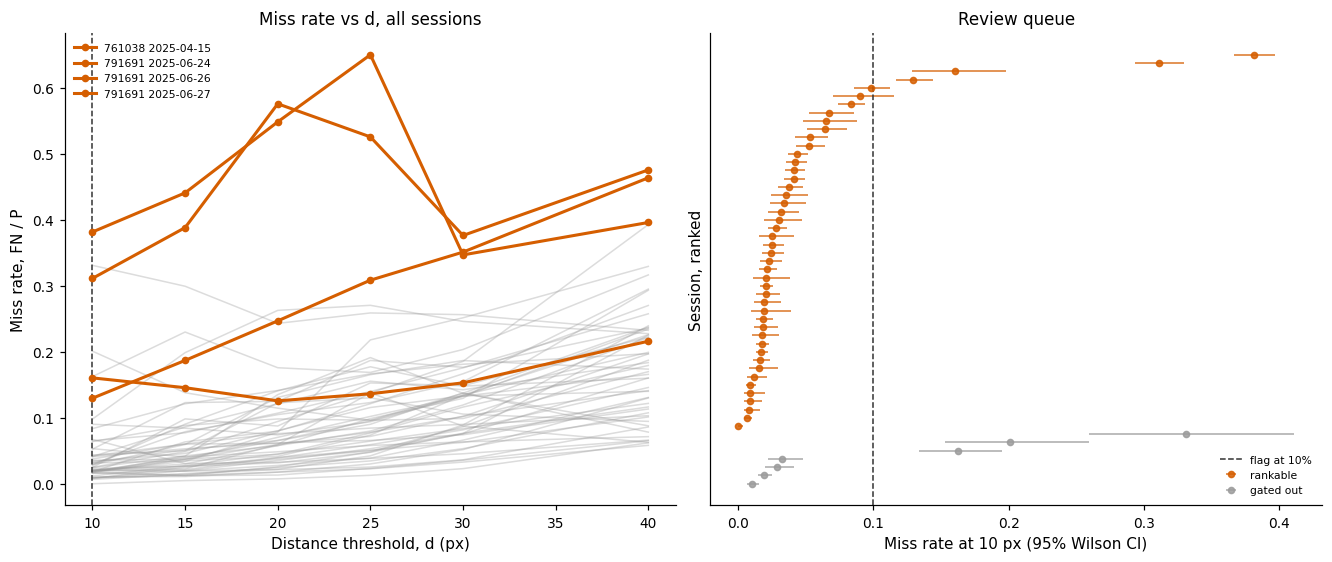

Sessions whose Wilson lower bound clears 10%:


,session,miss_rate,miss_lo,miss_hi,n_pose,lick_coverage,misses_per_min
0,behavior_791691_2025-06-24_13-21-26,0.3816,0.3665,0.3969,3928,0.9979,15.4136
1,behavior_791691_2025-06-26_13-39-22,0.3113,0.2933,0.3298,2464,0.9978,8.4652
2,behavior_761038_2025-04-15_10-24-57,0.1605,0.1288,0.1981,430,0.9995,1.8330
3,behavior_791691_2025-06-27_13-54-27,0.1297,0.1165,0.1441,2283,0.9992,3.5775


Gated out (n_pose < 300 or coverage < 90%):


,session,miss_rate,n_pose,lick_coverage
46,behavior_763590_2025-05-02_11-07-07,0.3310,145,0.9482
47,behavior_763590_2025-05-01_10-59-16,0.2009,214,0.9954
48,behavior_752014_2025-03-25_12-09-16,0.1625,554,0.7154
49,behavior_754897_2025-03-13_11-20-39,0.0324,710,0.8375
50,behavior_751181_2025-02-26_11-51-15,0.0287,1010,0.4846
51,behavior_717259_2024-06-28_11-17-19,0.0194,2682,0.8792
52,behavior_758017_2025-02-04_11-57-33,0.0103,2033,0.8374


In [15]:
if not IS_CO or not len(curves_df):
    print("[skip] Needs the sweep above.")
else:
    flagged_sessions = qc[qc["rankable"] & (qc["miss_lo"] > FLAG_MISS)]

    fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

    # -- panel 1: miss_rate(d), one line per session --
    hot = set(flagged_sessions["session"])
    for sess, g in curves_df.groupby("session"):
        g = g.sort_values("d")
        is_hot = sess in hot
        axs[0].plot(g["d"], g["miss_rate"], "-o" if is_hot else "-",
                    color=C_POSE if is_hot else C_NEUTRAL,
                    lw=2 if is_hot else 1, ms=4, alpha=1.0 if is_hot else 0.35,
                    zorder=3 if is_hot else 1,
                    label="{} {}".format(sess.split("_")[1], sess.split("_")[2])
                    if is_hot else None)
    axs[0].axvline(D0, color=PALETTE["all"], ls="--", lw=1)
    axs[0].set_xlabel("Distance threshold, d (px)")
    axs[0].set_ylabel("Miss rate, FN / P")
    axs[0].set_title("Miss rate vs d, all sessions")
    axs[0].legend(fontsize=7, loc="upper left", framealpha=0.9)

    # -- panel 2: the review queue --
    y = np.arange(len(qc))
    for lbl, mask, col in [("rankable", qc["rankable"], C_POSE),
                           ("gated out", ~qc["rankable"], C_NEUTRAL)]:
        sub = qc[mask]
        if not len(sub):
            continue
        axs[1].errorbar(sub["miss_rate"], y[mask.to_numpy()],
                        xerr=[sub["miss_rate"] - sub["miss_lo"],
                              sub["miss_hi"] - sub["miss_rate"]],
                        fmt="o", ms=4, lw=1, color=col, ecolor=col, alpha=0.85, label=lbl)
    axs[1].axvline(FLAG_MISS, color=PALETTE["all"], ls="--", lw=1,
                   label="flag at {:.0%}".format(FLAG_MISS))
    axs[1].invert_yaxis()
    axs[1].set_yticks([])
    axs[1].set_xlabel("Miss rate at {} px (95% Wilson CI)".format(D0))
    axs[1].set_ylabel("Session, ranked")
    axs[1].set_title("Review queue")
    axs[1].legend(fontsize=7, loc="lower right")

    for ax in axs:
        style_ax(ax)
    save_fig(fig, "fig2_miss_rate_by_session", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    print("Sessions whose Wilson lower bound clears {:.0%}:".format(FLAG_MISS))
    display(flagged_sessions[["session", "miss_rate", "miss_lo", "miss_hi", "n_pose",
                              "lick_coverage", "misses_per_min"]].round(4))
    print("Gated out (n_pose < {} or coverage < {:.0%}):".format(MIN_N_POSE, MIN_LICK_COVERAGE))
    display(qc[~qc["rankable"]][["session", "miss_rate", "n_pose", "lick_coverage"]].round(4))

### Reading the output

The median session has a miss rate of 2.8%, and the range across sessions is 0.0% to 38.2%. Of the
46 sessions that clear both gates, four have a lower bound above 10%: `791691` on three of its four
days, and `761038` on one of four.

The gates remove seven sessions. `763590` scores 20.1% and 33.1% but has only 214 and 145 pose
licks, so its intervals are 11 and 15 points wide. Five more fall below 90% `lick_coverage`,
including `752014 2025-03-25`, which scores 16.2% on a coverage of 71.5%: pose lost the tongue on
almost a third of that session's lickometer events, so its false negatives cannot be read as
lickometer failures.

`lick_coverage` sits above 97% in most sessions and drops sharply in a few, running to 48.5% at the
low end, so it separates sessions where pose could establish the actual condition from sessions
where it could not.

## 4. Day-to-day range within an animal

The same miss rate, grouped by subject. The sessions within a subject were recorded on consecutive
days, so the animal's licking should be fairly similar across them, and the camera and spout
placement stay roughly the same.

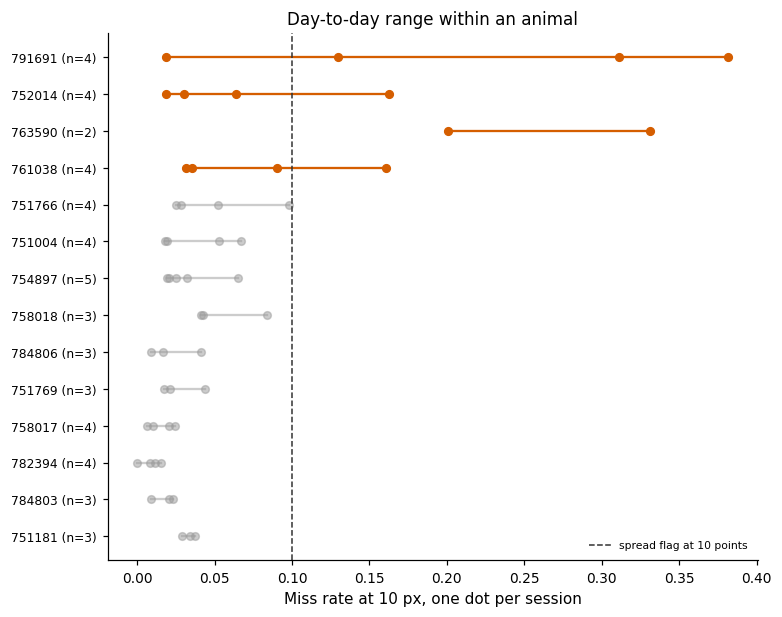

,n_sessions,lo,hi,median,spread
subject,,,,,
791691,4,0.0185,0.3816,0.2205,0.3631
752014,4,0.0184,0.1625,0.0469,0.1441
763590,2,0.2009,0.3310,0.2660,0.1301
761038,4,0.0315,0.1605,0.0628,0.1289
751766,4,0.0249,0.0980,0.0403,0.0731
751004,4,0.0179,0.0673,0.0363,0.0494
754897,5,0.0191,0.0651,0.0250,0.0460
758018,3,0.0411,0.0836,0.0422,0.0424
784806,3,0.0087,0.0410,0.0169,0.0323


Subjects with a day-to-day range above 10 points: 791691, 752014, 763590, 761038


In [16]:
if not IS_CO or not len(curves_df):
    print("[skip] Needs the sweep above.")
else:
    by_subject = (qc.groupby("subject")
                    .agg(n_sessions=("miss_rate", "size"), lo=("miss_rate", "min"),
                         hi=("miss_rate", "max"), median=("miss_rate", "median"))
                    .assign(spread=lambda t: t["hi"] - t["lo"])
                    .sort_values("spread", ascending=False))
    multi = by_subject[by_subject["n_sessions"] >= 2]
    flagged_subjects = multi[multi["spread"] > FLAG_SPREAD]

    fig, ax = plt.subplots(figsize=(7, 5.5), layout="constrained")
    for i, (subject, row) in enumerate(multi.iterrows()):
        is_hot = subject in flagged_subjects.index
        col = C_POSE if is_hot else C_NEUTRAL
        ax.plot([row["lo"], row["hi"]], [i, i], "-", color=col, lw=1.5,
                alpha=1.0 if is_hot else 0.5, zorder=2 if is_hot else 1)
        pts = qc.loc[qc["subject"] == subject, "miss_rate"]
        ax.plot(pts, np.full(len(pts), i), "o", ms=5, color=col,
                alpha=1.0 if is_hot else 0.5, zorder=3 if is_hot else 1)
    ax.axvline(FLAG_SPREAD, color=PALETTE["all"], ls="--", lw=1,
               label="spread flag at {:.0f} points".format(100 * FLAG_SPREAD))
    ax.set_yticks(np.arange(len(multi)))
    ax.set_yticklabels(["{} (n={})".format(s, int(r["n_sessions"]))
                        for s, r in multi.iterrows()], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Miss rate at {} px, one dot per session".format(D0))
    ax.set_title("Day-to-day range within an animal")
    ax.legend(fontsize=7, loc="lower right")
    style_ax(ax)
    save_fig(fig, "fig3_within_subject_spread", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    display(multi.round(4))
    print("Subjects with a day-to-day range above {:.0f} points: {}".format(
        100 * FLAG_SPREAD, ", ".join(flagged_subjects.index)))

### Reading the output

`791691` gives 38.2%, 1.9%, 31.1% and 13.0% on 24-27 June 2025. For comparison, `782394` gives
1.6%, 1.2%, 0.8% and 0.0% across its four days, and 10 of the 14 animals with more than one session
stay within a range of 8 points.

Four animals have a range above 10 points: `791691` (36.3), `752014` (14.4), `763590` (13.0) and
`761038` (12.9). Two of them, `791691` and `761038`, are the animals flagged in §3. The other two
are animals §3's gates excluded, `752014` on `lick_coverage` and `763590` on `n_pose`.

## 5. Limitations

1. Pose licks stand in for real licks, and they are an imperfect substitute. A false negative is
   only a candidate: the lickometer may have failed, or the tongue may have come within `d` of the
   spout without touching it, or the keypoint may have been wrong. Deciding which requires looking
   at the video, and no events have been scored by eye yet, so the rate at which pose calls a lick
   that did not happen is unknown, and it sits underneath every number above. Cutting the video
   clips for that review is not done here.
2. The choice of `d` biases the result in both directions. If the lickometer tends to fail on
   glancing contacts, those licks are further from the spout and get excluded at 10 px, which makes
   the miss rate look lower than it is. At the same time, a tongue that passes within 10 px without
   touching the spout counts as a pose lick, and the lickometer not firing for it is counted as a
   miss, which makes the rate look higher.
3. A pixel is not the same physical distance in every session. Jaw-to-endpoint distance during
   licking ranges from 53 to 95 px across the set, so 10 px means something different from one
   session to the next. Comparing sessions within a single animal avoids most of this.
4. Some of the difference between sessions may be behavioural rather than instrumental. An animal
   that makes more near-spout tongue movements without contacting produces more false negatives at
   the same lickometer performance. Nothing measured here constrains the size of that effect:
   any covariate built from the count of pose licks is also the denominator of the miss rate, so it
   moves with the quantity it is meant to control for.
5. Detection uses `tongue_tip_center` from a single camera, and the spout position is an average
   over the whole session. If a spout is moved partway through, the distance trace is wrong for
   part of the session.
6. `behavior_856239_2026-07-24` has no pose output, so the session reported in #96 is not
   reproduced here. These rates come from 53 other sessions recorded between 2024-05-31 and
   2025-07-03.
7. `detect_licks` takes the first frame of each run below `d`, and it works on the tracked frames
   with the untracked ones removed, so a gap in tracking is invisible to it. An excursion that
   dips below `d`, loses tracking, and comes back below `d` is counted once rather than twice,
   however long the gap. The effect grows as tracking gets patchier, which ties the pose lick
   count to `lick_coverage` in a way the gate does not remove.

## 6. Two QC metrics

### A. Session miss rate at 10 px

```
gate   n_pose >= 300  and  lick_coverage >= 0.90
flag   Wilson 95% lower bound of miss_rate(10 px) > 0.10
```

This gives one number per session and needs nothing beyond the intermediates the pose pipeline
already writes. The gates pass 46 of the 53 sessions, and of those, four are flagged, against a
median session of 2.8%. The gates are there because a false negative count means little if pose was
not tracking well enough to establish the actual condition (`lick_coverage`) or if there were too
few pose licks for the interval to be narrow (`n_pose`). Both do real work here: five sessions fail
on coverage and two on event count, and one of the five, `752014 2025-03-25`, would otherwise have
been flagged at 16.2%. A flagged session would go to someone for review, along with clips of its
closest false negatives.

Limitations 1, 3 and 4 apply here: the rate includes pose licks that were not real licks, it
depends on the pixel scale of that particular session, and it partly reflects how much the animal
licked.

### B. Day-to-day range within a subject

```
require  >= 3 sessions for the subject
flag     max(miss_rate) - min(miss_rate) across sessions > 0.10
```

Metric A can be high for reasons that have nothing to do with the lickometer, such as a dark or
badly framed video, or an animal that moves its tongue a lot. Those conditions tend to be similar
on consecutive days in the same animal, whereas an intermittent hardware fault is not, so a large
day-to-day range is better evidence of a hardware problem than a single high session. Keeping the
animal fixed also keeps the camera geometry roughly fixed, which removes limitation 3. On this set
it flags 3 of the 14 animals with more than one session, covering 12 sessions, and it indicates
which day to look at. One of the three is `752014`, which A's coverage gate held back. `763590` has
a 13.0-point range but only two sessions, so it misses the three-session requirement and neither
metric reaches it.

Used together, A gives a ranked list of sessions to review and B indicates whether a high rate is
more likely to be the rig or the animal.

In [17]:
if not IS_CO or not len(curves_df):
    print("[skip] Needs the analysis above.")
else:
    qc_table = qc[["session", "subject", "duration_s", "n_pose", "n_matched", "n_pose_only",
                   "n_lickometer_only", "miss_rate", "miss_lo", "miss_hi", "precision",
                   "misses_per_min", "lick_coverage"]].copy()
    qc_table["d_px"] = D0
    qc_table["gate_pass"] = qc["rankable"].values
    # A: session-level flag.
    qc_table["flag_session"] = qc_table["gate_pass"] & (qc_table["miss_lo"] > FLAG_MISS)
    # B: subject-level flag, broadcast onto the subject's sessions.
    spread = (qc_table.groupby("subject")["miss_rate"]
              .agg(["min", "max", "size"]).rename(columns={"size": "n_sessions"}))
    spread["subject_spread"] = spread["max"] - spread["min"]
    spread["flag_subject"] = (spread["n_sessions"] >= 3) & (spread["subject_spread"] > FLAG_SPREAD)
    qc_table = qc_table.merge(spread[["n_sessions", "subject_spread", "flag_subject"]],
                              left_on="subject", right_index=True, how="left")
    qc_table["flag_any"] = qc_table["flag_session"] | qc_table["flag_subject"]

    FIG_DIR.mkdir(parents=True, exist_ok=True)
    out = FIG_DIR / "val_04_lickometer_qc.csv"
    qc_table.sort_values("miss_rate", ascending=False).to_csv(out, index=False)

    print("wrote {}  ({} sessions)".format(out, len(qc_table)))
    print("  A, session flag:  {}".format(int(qc_table["flag_session"].sum())))
    print("  B, subject flag:  {} sessions across {} subjects".format(
        int(qc_table["flag_subject"].sum()),
        int(qc_table.loc[qc_table["flag_subject"], "subject"].nunique())))
    print("  either:           {}".format(int(qc_table["flag_any"].sum())))
    display(qc_table[qc_table["flag_any"]]
            .sort_values("miss_rate", ascending=False)
            [["session", "miss_rate", "miss_lo", "n_pose", "subject_spread",
              "flag_session", "flag_subject"]].round(4))

wrote /root/capsule/scratch/figures/val_04_lickometer_qc/val_04_lickometer_qc.csv  (53 sessions)
  A, session flag:  4
  B, subject flag:  12 sessions across 3 subjects
  either:           12


,session,miss_rate,miss_lo,n_pose,subject_spread,flag_session,flag_subject
0,behavior_791691_2025-06-24_13-21-26,0.3816,0.3665,3928,0.3631,True,True
1,behavior_791691_2025-06-26_13-39-22,0.3113,0.2933,2464,0.3631,True,True
48,behavior_752014_2025-03-25_12-09-16,0.1625,0.1341,554,0.1441,False,True
2,behavior_761038_2025-04-15_10-24-57,0.1605,0.1288,430,0.1289,True,True
3,behavior_791691_2025-06-27_13-54-27,0.1297,0.1165,2283,0.3631,True,True
5,behavior_761038_2025-04-16_10-39-06,0.0902,0.0701,621,0.1289,False,True
9,behavior_752014_2025-03-28_11-04-56,0.0639,0.0507,1064,0.1441,False,True
17,behavior_761038_2025-04-17_11-03-12,0.0355,0.0243,733,0.1289,False,True
19,behavior_761038_2025-04-18_12-37-37,0.0315,0.0219,888,0.1289,False,True
20,behavior_752014_2025-03-26_11-18-52,0.0300,0.0190,601,0.1441,False,True


## 7. Example missed licks

One session flagged by both metrics, with the distance-to-spout trace around ten of its false
negatives and a video clip for each. `EXAMPLE_OVERRIDE` in the cell below picks a different
session, and `EXAMPLE_SEED` a different ten events; §8 follows whatever §7 chose. A false negative is a pose lick with no lickometer event
within 100 ms, so these are the candidate missed licks from §1, drawn at random rather than picked.

The clips are cut from the labeled video, which carries the keypoint overlay, so a misplaced
`tongue_tip_center` is visible in the frame.

In [ ]:
# Which session §7 and §8 use. Leave EXAMPLE_OVERRIDE as None to take the session flagged
# by both metrics with the highest miss rate. Set it to any part of a session name to pick
# one yourself, e.g. "791691_2025-06-26", "761038" or a full session id. The session has to
# be one the §3 sweep covered, since its counts come from qc_table.
EXAMPLE_OVERRIDE = None

N_EXAMPLES   = 10     # false negatives to show
CLIP_LENGTH  = 1.0    # s, centred on the event
EXAMPLE_SEED = 0      # fixes which ten are drawn; change it to draw a different ten

example = None
if not IS_CO or not len(curves_df):
    print("[skip] Needs the analysis above.")
else:
    both = (qc_table[qc_table["flag_session"] & qc_table["flag_subject"]]
            .sort_values("miss_rate", ascending=False))
    print("Flagged by both metrics:")
    display(both[["session", "miss_rate", "miss_lo", "n_pose", "n_pose_only",
                  "subject_spread"]].round(4))

    if EXAMPLE_OVERRIDE is not None:
        hit = qc_table[qc_table["session"].str.contains(EXAMPLE_OVERRIDE, regex=False)]
        if len(hit) == 1:
            example = hit.iloc[0]
            print("\nEXAMPLE_OVERRIDE {!r} matched {}.".format(
                EXAMPLE_OVERRIDE, example["session"]))
        elif len(hit) == 0:
            print("\n[skip] No session matches {!r}. The sweep covered:".format(
                EXAMPLE_OVERRIDE))
            for s in sorted(qc_table["session"]):
                print("   ", s)
        else:
            print("\n[skip] {!r} matches {} sessions, narrow it:".format(
                EXAMPLE_OVERRIDE, len(hit)))
            for s in sorted(hit["session"]):
                print("   ", s)
    elif not len(both):
        print("\n[skip] No session is flagged by both metrics."
              " Set EXAMPLE_OVERRIDE to choose one.")
    else:
        example = both.iloc[0]
        print("\nAutomatic pick: highest miss rate among the sessions flagged by both.")

    if example is not None:
        print("Using {}: miss rate {:.1%}, {:,} false negatives of {:,} pose licks,"
              " subject day-to-day range {:.1f} points.".format(
                  example["session"], example["miss_rate"], int(example["n_pose_only"]),
                  int(example["n_pose"]), 100 * example["subject_spread"]))
        if not (example["flag_session"] and example["flag_subject"]):
            print("  note: this session is not flagged by both metrics"
                  " (flag_session={}, flag_subject={}).".format(
                      bool(example["flag_session"]), bool(example["flag_subject"])))

        inter_ex = find_session_dir(example["session"], roots=[SESSION_DIR]) / "intermediate_data"
        with contextlib.redirect_stdout(io.StringIO()):
            S_ex = load_session(inter_ex)
            ref_ex = classify_events(S_ex, D0)

        fn_times = np.asarray(ref_ex["pose_only_times"], dtype=float)
        if fn_times.size == 0:
            print("  no false negatives at {} px, nothing to plot.".format(D0))
            example = None
        else:
            rng_ex = np.random.default_rng(EXAMPLE_SEED)
            picks = np.sort(rng_ex.choice(fn_times, size=min(N_EXAMPLES, fn_times.size),
                                          replace=False))
            print("Drew {} of {:,} false negatives at {} px.".format(
                len(picks), fn_times.size, D0))

In [ ]:
if not IS_CO or example is None:
    print("[skip] Needs the session above.")
else:
    # Half a clip either side, so each panel spans exactly the window its clip covers.
    HALFWIN = CLIP_LENGTH / 2.0
    ncol = 5
    nrow = int(np.ceil(len(picks) / float(ncol)))

    fig, axs = plt.subplots(nrow, ncol, figsize=(2.6 * ncol, 2.5 * nrow),
                            sharey=True, layout="constrained", squeeze=False)
    tg_ex = S_ex["tongue"]
    # The classified event lists, so the panels show what the detector produced rather than
    # every frame that happened to fall below d.
    pose_ev = ref_ex["pose_lick_times"]
    licks_ex = ref_ex["lickometer_times"]
    nearest_lick = []
    for k, t0 in enumerate(picks):
        ax = axs[k // ncol][k % ncol]
        win = tg_ex[(tg_ex["time"] >= t0 - HALFWIN) & (tg_ex["time"] <= t0 + HALFWIN)]
        # spout_distance is NaN below the confidence floor, so the trace breaks wherever
        # the tongue is not tracked.
        ax.plot(win["time"] - t0, win["spout_distance"], ".-", ms=3, lw=1, color=C_POSE)

        # The match window. A lickometer event inside it would have made this a true
        # positive, so the band is empty for a false negative unless an earlier pose lick
        # had already claimed that event.
        ax.axvspan(-MATCH_WINDOW, MATCH_WINDOW, color=PALETTE["neutral"], alpha=0.10, lw=0)

        # Two event rasters: detected pose licks along the top, lickometer along the
        # bottom. The trace crosses d far more often than either fires, because one run
        # below d yields one event and the refractory filter drops anything within 100 ms.
        pe = pose_ev[(pose_ev >= t0 - HALFWIN) & (pose_ev <= t0 + HALFWIN)]
        if pe.size:
            ax.plot(pe - t0, np.full(pe.size, 116.0), "|", ms=9, mew=1.5, color=C_POSE)
        lk = licks_ex[(licks_ex >= t0 - HALFWIN) & (licks_ex <= t0 + HALFWIN)]
        if lk.size:
            ax.plot(lk - t0, np.full(lk.size, 4.0), "|", ms=9, mew=1.5, color=C_LICKO)
        nearest_lick.append(np.min(np.abs(licks_ex - t0)) if licks_ex.size else np.nan)

        ax.axvline(0, color=PALETTE["neutral"], ls="--", lw=1)
        ax.axhline(D0, color=PALETTE["all"], ls=":", lw=1)
        # Pin both axes: the trace exists only on tracked frames, so autoscaling would give
        # every panel a different time span.
        ax.set_xlim(-HALFWIN, HALFWIN)
        ax.set_ylim(0, 120)
        # Panel k is clip k: both come from picks[k - 1], in this order.
        ax.set_title("clip {} · {:.1f} s".format(k + 1, t0), fontsize=8)
        if k % ncol == 0:
            ax.set_ylabel("Distance to spout (px)")
        if k // ncol == nrow - 1:
            ax.set_xlabel("Time from event (s)")
        style_ax(ax)
    for k in range(len(picks), nrow * ncol):
        axs[k // ncol][k % ncol].axis("off")

    # A proxy handle, so the legend appears whether or not the first panel has any ticks.
    axs[0][0].legend(handles=[Line2D([], [], color=C_POSE, marker="|", ms=9, mew=1.5,
                                     ls="none", label="pose lick"),
                              Line2D([], [], color=C_LICKO, marker="|", ms=9, mew=1.5,
                                     ls="none", label="lickometer")],
                     fontsize=7, loc="center right")
    fig.suptitle("{} — false negatives at {} px (dashed = event, dotted = {} px,"
                 " shaded = {:.0f} ms match window)".format(
                     example["session"], D0, D0, 1000 * MATCH_WINDOW), fontsize=10)
    save_fig(fig, "fig4_example_missed_licks", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    # Threshold crossings against detected events, across the ten plotted windows.
    n_frames_below, n_events = 0, 0
    for t0 in picks:
        w = tg_ex[(tg_ex["time"] >= t0 - HALFWIN) & (tg_ex["time"] <= t0 + HALFWIN)]
        n_frames_below += int((w["spout_distance"] <= D0).sum())
        n_events += int(((pose_ev >= t0 - HALFWIN) & (pose_ev <= t0 + HALFWIN)).sum())
    print("Across the ten windows: {:,} frames below {} px, {} detected pose licks.".format(
        n_frames_below, D0, n_events))

    nearest_lick = np.asarray(nearest_lick, dtype=float)
    print("Nearest lickometer event to each drawn false negative (ms):")
    print("  " + "  ".join("{:.0f}".format(1000 * g) for g in nearest_lick))
    print("  inside the {:.0f} ms match window: {} of {}".format(
        1000 * MATCH_WINDOW, int((nearest_lick <= MATCH_WINDOW).sum()), len(nearest_lick)))
    print("  inside the plotted +/-{:.0f} ms window: {} of {}".format(
        1000 * HALFWIN, int((nearest_lick <= HALFWIN).sum()), len(nearest_lick)))

### Why these events are false negatives

A panel can show a pose lick and a lickometer tick close together and still be scored a false
negative. Three things produce that, and this cell measures which one is operating.

The refractory filter does not prevent any of them. It caps each stream at one event per 100 ms
separately, so it removes repeat detections within a stream and nothing else. It cannot create a
lickometer event where there is none, and it cannot move two streams onto the same clock. It also
only binds when a stream reaches the cap: six pose licks 120 ms apart against three lickometer
events 240 ms apart pass through it untouched and still score a 50% miss rate.

**Event-count floor.** The matcher pairs each lickometer event with at most one pose lick, so
`FN >= n_pose - n_lickometer` and

```
miss rate >= 1 - n_lickometer / n_pose
```

If pose fires twice as often as the lickometer, half the pose licks are false negatives whatever the
lickometer did. This floor is a property of the detector pair, not of the hardware.

**Consumption.** `calculate_metrics_witheventkeys` walks both lists once and takes the first pair
within the window. A lickometer event claimed by one pose lick is gone, so the next pose lick 70 ms
later is a false negative with a tick sitting inside its match window.

**A clock offset.** The matcher needs the two streams on the same clock. A constant lead or lag
larger than `MATCH_WINDOW` sends every event to false negative and false positive together, with
`TP` near zero.

In [ ]:
if not IS_CO or example is None:
    print("[skip] Needs the section 7 session.")
else:
    pose_ev_all = ref_ex["pose_lick_times"]
    licko_all = ref_ex["lickometer_times"]
    fn_all = np.asarray(ref_ex["pose_only_times"], dtype=float)
    n_licko_all = ref_ex["n_matched"] + ref_ex["n_lickometer_only"]

    print("{} at d = {} px".format(example["session"], D0))
    print("  pose licks       {:>6,}".format(ref_ex["n_pose"]))
    print("  lickometer       {:>6,}".format(n_licko_all))
    print("  ratio pose/licko {:>6.2f}".format(ref_ex["n_pose"] / float(max(n_licko_all, 1))))

    floor = max(0.0, 1.0 - n_licko_all / float(max(ref_ex["n_pose"], 1)))
    print("\n  miss rate            {:.4f}".format(ref_ex["miss_rate"]))
    print("  floor from the counts {:.4f}  (1 - n_lickometer / n_pose)".format(floor))
    print("  above the floor       {:.4f}".format(ref_ex["miss_rate"] - floor))

    # Split the false negatives by whether a lickometer event sat inside the match window.
    if fn_all.size and licko_all.size:
        idx = np.searchsorted(licko_all, fn_all)
        best = np.full(fn_all.size, np.inf)
        for off in (-1, 0):
            j = np.clip(idx + off, 0, licko_all.size - 1)
            cand = licko_all[j] - fn_all
            best = np.where(np.abs(cand) < np.abs(best), cand, best)
        claimed = int((np.abs(best) <= MATCH_WINDOW).sum())
        print("\n  false negatives {:,}".format(fn_all.size))
        print("    with a lickometer event inside the {:.0f} ms window: {:,} ({:.1%})".format(
            1000 * MATCH_WINDOW, claimed, claimed / float(fn_all.size)))
        print("      these had one in reach; it was matched to a different pose lick")
        print("    with none inside the window:                    {:,} ({:.1%})".format(
            fn_all.size - claimed, 1 - claimed / float(fn_all.size)))

    # A systematic lead or lag shows up as an offset distribution off zero.
    if pose_ev_all.size and licko_all.size:
        idx = np.searchsorted(licko_all, pose_ev_all)
        best = np.full(pose_ev_all.size, np.inf)
        for off in (-1, 0):
            j = np.clip(idx + off, 0, licko_all.size - 1)
            cand = licko_all[j] - pose_ev_all
            best = np.where(np.abs(cand) < np.abs(best), cand, best)
        q = np.percentile(best, [25, 50, 75]) * 1000
        print("\n  pose lick -> nearest lickometer event (ms, positive = lickometer later)")
        print("    median {:+.0f}   IQR [{:+.0f}, {:+.0f}]".format(q[1], q[0], q[2]))
        print("    a median well outside +/-{:.0f} ms is a clock offset, not a hardware fault".format(
            1000 * MATCH_WINDOW))

        fig, ax = plt.subplots(figsize=(6, 3.2), layout="constrained")
        ax.hist(np.clip(best, -0.5, 0.5) * 1000, bins=np.arange(-500, 501, 10),
                color=C_POSE, alpha=0.85)
        ax.axvspan(-1000 * MATCH_WINDOW, 1000 * MATCH_WINDOW, color=PALETTE["neutral"],
                   alpha=0.15, lw=0)
        ax.axvline(0, color=PALETTE["all"], ls="--", lw=1)
        ax.set_xlabel("Nearest lickometer event relative to pose lick (ms)")
        ax.set_ylabel("Pose licks")
        ax.set_title("{} — stream alignment".format(example["session"]), fontsize=10)
        style_ax(ax)
        save_fig(fig, "fig6_stream_alignment", fig_dir=FIG_DIR, save=SAVE_FIG)
        plt.show()

#### Is it the matcher, or is pose double-counting single licks?

A false negative with a lickometer event inside its window means that event was matched to a
neighbouring pose lick. Two things can produce that.

The matcher could be leaving matches on the table. `calculate_metrics_witheventkeys` pairs greedily
in one pass, which is not obviously optimal. The cell below re-matches the same two event lists with
an order-preserving maximum matching and reports whether it finds more pairs.

Or pose is reporting one lick twice. `detect_licks` starts a new event every time the trace
re-enters `d`, and the refractory filter only merges events closer than 100 ms, so a trace that
wobbles across the threshold on a 120 ms cycle yields two pose licks for one contact. The second
has no lickometer event left to claim. The signature is a false negative sitting one wobble away
from a true positive, so the cell also reports the gap from each false negative to the nearest
other pose lick.

In [ ]:
def match_events_optimal(actual, predicted, window):
    """Order-preserving maximum matching between two event trains.

    Pairs are allowed when ``|actual_i - predicted_j| <= window``; each event is used at
    most once. Returns ``(n_matched, fn_times, fp_times)``. For sorted events on a line an
    order-preserving optimum is a global optimum, so this is an upper bound on any matcher.
    """
    a = np.sort(np.asarray(actual, dtype=float))
    d = np.sort(np.asarray(predicted, dtype=float))
    if a.size == 0 or d.size == 0:
        return 0, a.copy(), d.copy()

    # Only events within one window can interact: split the merged timeline at larger gaps
    # and solve each block, which keeps the DP tables small.
    merged = np.concatenate([a, d])
    is_a = np.concatenate([np.ones(a.size, bool), np.zeros(d.size, bool)])
    order = np.argsort(merged, kind="mergesort")
    merged, is_a = merged[order], is_a[order]
    a_pos = np.cumsum(is_a) - 1
    d_pos = np.cumsum(~is_a) - 1
    bounds = np.concatenate([[0], np.flatnonzero(np.diff(merged) > window) + 1, [merged.size]])

    pairs = []
    for lo, hi in zip(bounds[:-1], bounds[1:]):
        blk = slice(lo, hi)
        ia, jd = a_pos[blk][is_a[blk]], d_pos[blk][~is_a[blk]]
        if ia.size == 0 or jd.size == 0:
            continue
        ok = np.abs(a[ia][:, None] - d[jd][None, :]) <= window
        dp = np.zeros((ia.size + 1, jd.size + 1), dtype=np.int32)
        for i in range(1, ia.size + 1):
            dp[i, 1:] = np.maximum.accumulate(
                np.maximum(dp[i - 1, 1:], dp[i - 1, :-1] + ok[i - 1]))
        i, j = ia.size, jd.size
        while i > 0 and j > 0:
            if dp[i, j] == dp[i - 1, j]:
                i -= 1
            elif dp[i, j] == dp[i, j - 1]:
                j -= 1
            else:
                pairs.append((ia[i - 1], jd[j - 1]))
                i -= 1
                j -= 1
    ma = {i for i, _ in pairs}
    md_ = {j for _, j in pairs}
    return (len(pairs),
            np.array([a[i] for i in range(a.size) if i not in ma]),
            np.array([d[j] for j in range(d.size) if j not in md_]))


if not IS_CO or example is None:
    print("[skip] Needs the section 7 session.")
else:
    pose_ev_all = ref_ex["pose_lick_times"]
    licko_all = ref_ex["lickometer_times"]
    fn_all = np.asarray(ref_ex["pose_only_times"], dtype=float)

    # 1. Could any matcher do better on these same two lists?
    n_opt, fn_opt, _ = match_events_optimal(pose_ev_all, licko_all, MATCH_WINDOW)
    print("matched pairs")
    print("  greedy (library)        {:>6,}".format(ref_ex["n_matched"]))
    print("  order-preserving optimum{:>6,}".format(n_opt))
    print("  recovered by optimising {:>6,}".format(n_opt - ref_ex["n_matched"]))
    if n_opt > ref_ex["n_matched"]:
        print("  -> the greedy pass is losing matches on real data; the miss rate is inflated")
        print("     by {:.4f}".format((n_opt - ref_ex["n_matched"]) / float(ref_ex["n_pose"])))
    else:
        print("  -> the matcher is already optimal, so the false negatives are forced by the")
        print("     event lists themselves")

    # 2. How close is each false negative to the nearest OTHER pose lick?
    if fn_all.size and pose_ev_all.size > 1:
        gaps = []
        for t in fn_all:
            other = pose_ev_all[pose_ev_all != t]
            gaps.append(np.min(np.abs(other - t)) if other.size else np.nan)
        gaps = np.asarray(gaps, dtype=float) * 1000.0
        q = np.nanpercentile(gaps, [25, 50, 75])
        print("\nfalse negative -> nearest other pose lick (ms)")
        print("  median {:.0f}   IQR [{:.0f}, {:.0f}]".format(q[1], q[0], q[2]))
        print("  within 250 ms of another pose lick: {:,} of {:,} ({:.1%})".format(
            int((gaps <= 250).sum()), gaps.size, (gaps <= 250).mean()))
        print("  a cluster just above the {:.0f} ms refractory period means pose split one".format(
            1000 * T_REFRACTORY))
        print("  contact into two events that the filter was too short to merge")

        fig, ax = plt.subplots(figsize=(6, 3.2), layout="constrained")
        ax.hist(np.clip(gaps, 0, 600), bins=np.arange(0, 601, 20), color=C_POSE, alpha=0.85)
        ax.axvline(1000 * T_REFRACTORY, color=PALETTE["all"], ls="--", lw=1,
                   label="refractory {:.0f} ms".format(1000 * T_REFRACTORY))
        ax.set_xlabel("Gap from false negative to nearest other pose lick (ms)")
        ax.set_ylabel("False negatives")
        ax.set_title("{} — are false negatives split detections?".format(example["session"]),
                     fontsize=10)
        ax.legend(fontsize=7)
        style_ax(ax)
        save_fig(fig, "fig7_split_detections", fig_dir=FIG_DIR, save=SAVE_FIG)
        plt.show()

In [ ]:
if not IS_CO or example is None:
    print("[skip] Needs the session above.")
else:
    try:
        labeled_video = find_labeled_video(example["session"], DATA)
    except FileNotFoundError as exc:
        labeled_video = None
        print("[skip] {}".format(exc))
        print("       find_labeled_video looks for <DATA>/<session>*/pred_outputs/"
              "video_preds/labeled_videos/*_labeled.mp4")

    if labeled_video is not None:
        # Session time -> video time, then back up half a clip so the event sits in the middle.
        starts = session_time_to_video_time(picks, S_ex["video_offset"]) - CLIP_LENGTH / 2.0
        out_dir = FIG_DIR / "clips" / example["session"]
        print("Labeled video: {}".format(labeled_video))
        print("Video offset:  {:.3f} s (session time + this = video time)".format(
            S_ex["video_offset"]))
        print("Writing {} clips of {:.1f} s each to {}".format(
            len(starts), CLIP_LENGTH, out_dir))
        # extract_clips_ffmpeg_encode re-encodes, so the cut lands on the requested frame.
        # The stream-copy version snaps to the nearest preceding keyframe, which is too
        # coarse for a 1 s clip centred on one event.
        extract_clips_ffmpeg_encode(str(labeled_video), starts, CLIP_LENGTH, str(out_dir))
        # Panel k of the figure above is clip k here. The filename carries the same number,
        # as <video>_clip_<k>_<start>s_to_<end>s.mp4.
        print("  {:>4}  {:>12}  {:>12}  {:>17}".format(
            "clip", "event (sess)", "event (vid)", "clip span (vid)"))
        for k, (t0, v0) in enumerate(zip(picks, starts), 1):
            print("  {:>4}  {:>12.2f}  {:>12.2f}  {:>7.2f} - {:.2f}".format(
                k, t0, t0 + S_ex["video_offset"], v0, v0 + CLIP_LENGTH))

### Reading the output

A trace that drops below 10 px and stays there for several frames is a tongue that reached the
spout and remained. A trace that touches 10 px on a single frame, or arrives from far away between
consecutive frames, is a keypoint that moved further than a tongue can in 5 ms.

Each panel covers exactly the window its clip covers, and panel `n` is clip `n`, so the two can be
read side by side.

The ticks are the classified events: detected pose licks along the top, lickometer along the bottom,
both after the 100 ms refractory filter. The trace crosses 10 px far more often than a tick appears,
because `detect_licks` takes only the first frame of each run below `d` and the filter then drops
anything within 100 ms of the previous event. Counting crossings in the trace overstates the
detections by a large factor; the printed line gives both numbers.

The shaded band is the 100 ms match window. A
panel with no ticks anywhere is a stretch where the lickometer recorded nothing at all. A panel with
ticks just outside the band is a lickometer that fired close to the pose lick without falling inside
the window, which is a timing disagreement rather than a dropout. The printed list gives the gap to
the nearest lickometer event for each of the ten.

The clip decides whether the tongue reached the spout. Scoring these ten by eye gives the
false-positive rate that limitation 1 leaves unmeasured, for this session.

## 8. Confidence threshold

`CONF` = 0.8 came from `val_02` and has carried through the `val_*` series. The library's
`mask_keypoint_data` defaults to 0.9, and the batch pipeline in `tongue_analysis` masks at 0.90, so
these notebooks have been running below the rest of the codebase.

This section reloads the §7 session at 0.8 and 0.95 and overlays the distance-to-spout traces for
the same ten events, then reports what the session-level numbers do at each.

The clips in §7 are unaffected either way: their overlay is drawn by the Lightning Pose pipeline
when it renders `*_labeled.mp4`, at whatever likelihood cutoff that pipeline used, which is not
`CONF` and is not recorded here.

In [ ]:
CONF_COMPARE = [CONF, 0.95]

conf_sessions = {}
if not IS_CO or example is None:
    print("[skip] Needs the section 7 session.")
else:
    rows = []
    for conf in CONF_COMPARE:
        with contextlib.redirect_stdout(io.StringIO()):
            s_c = load_session(inter_ex, conf=conf)
            r_c = classify_events(s_c, D0)
        tg_c = s_c["tongue"]
        trk_c = tg_c.loc[tg_c["spout_distance"].notna(), ["time", "spout_distance"]]
        d_lick_c = min_distance_near(trk_c["time"].to_numpy(),
                                     trk_c["spout_distance"].to_numpy(),
                                     s_c["licks"], LICK_HALFWIN)
        lo_c, hi_c = wilson_ci(r_c["n_pose_only"], r_c["n_pose"])
        conf_sessions[conf] = s_c
        rows.append({"conf": conf,
                     # What the mask keeps. Reported here to show the threshold's effect on
                     # one session, rather than as a covariate across sessions.
                     "frames_kept": float(tg_c["x"].notna().mean()),
                     "n_pose": r_c["n_pose"], "n_matched": r_c["n_matched"],
                     "n_pose_only": r_c["n_pose_only"], "miss_rate": r_c["miss_rate"],
                     "miss_lo": lo_c, "recall": r_c["recall"], "precision": r_c["precision"],
                     "lick_coverage": float(np.mean(~np.isnan(d_lick_c)))})
    conf_df = pd.DataFrame(rows)
    print("{} at two confidence floors:".format(example["session"]))
    display(conf_df.round(4))

    print("Metric A needs lick_coverage >= {:.2f}, n_pose >= {} and miss_lo > {:.2f}:".format(
        MIN_LICK_COVERAGE, MIN_N_POSE, FLAG_MISS))
    for r in rows:
        gate = (r["lick_coverage"] >= MIN_LICK_COVERAGE) and (r["n_pose"] >= MIN_N_POSE)
        print("  conf {:.2f}:  coverage {:.4f}  n_pose {:>5,}  miss_lo {:.4f}  ->  {}".format(
            r["conf"], r["lick_coverage"], int(r["n_pose"]), r["miss_lo"],
            "FLAGGED" if (gate and r["miss_lo"] > FLAG_MISS) else
            ("not flagged" if gate else "gated out")))

In [ ]:
if not IS_CO or not conf_sessions:
    print("[skip] Needs the comparison above.")
else:
    HALFWIN_C = CLIP_LENGTH / 2.0   # same window as the §7 panels and clips
    ncol = 5
    nrow = int(np.ceil(len(picks) / float(ncol)))
    styles = [(CONF_COMPARE[0], C_POSE), (CONF_COMPARE[1], C_LICKO)]

    fig, axs = plt.subplots(nrow, ncol, figsize=(2.6 * ncol, 2.5 * nrow),
                            sharey=True, layout="constrained", squeeze=False)
    still_tracked = 0
    for k, t0 in enumerate(picks):
        ax = axs[k // ncol][k % ncol]
        for conf, col in styles:
            tg_c = conf_sessions[conf]["tongue"]
            win = tg_c[(tg_c["time"] >= t0 - HALFWIN_C) & (tg_c["time"] <= t0 + HALFWIN_C)]
            ax.plot(win["time"] - t0, win["spout_distance"], ".-", ms=3, lw=1, color=col,
                    label="conf >= {:.2f}".format(conf) if k == 0 else None)
        # Did the stricter floor keep anything at the event itself?
        tg_hi = conf_sessions[CONF_COMPARE[1]]["tongue"]
        near = tg_hi[(tg_hi["time"] >= t0 - MATCH_WINDOW) & (tg_hi["time"] <= t0 + MATCH_WINDOW)]
        still_tracked += int(near["spout_distance"].notna().any())
        ax.axvline(0, color=PALETTE["neutral"], ls="--", lw=1)
        ax.axhline(D0, color=PALETTE["all"], ls=":", lw=1)
        ax.set_xlim(-HALFWIN_C, HALFWIN_C)
        ax.set_ylim(0, 120)
        ax.set_title("clip {} · {:.1f} s".format(k + 1, t0), fontsize=8)
        if k % ncol == 0:
            ax.set_ylabel("Distance to spout (px)")
        if k // ncol == nrow - 1:
            ax.set_xlabel("Time from event (s)")
        style_ax(ax)
    for k in range(len(picks), nrow * ncol):
        axs[k // ncol][k % ncol].axis("off")

    axs[0][0].legend(fontsize=7, loc="upper right")
    fig.suptitle("{} — same ten events at two confidence floors".format(example["session"]),
                 fontsize=10)
    save_fig(fig, "fig5_confidence_comparison", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    print("Events with a tracked tongue within +/-{:.0f} ms of the event at conf >= {:.2f}:"
          " {} of {}".format(1000 * MATCH_WINDOW, CONF_COMPARE[1], still_tracked, len(picks)))

### Reading the output

Where the two traces lie on top of each other, the frames were already above 0.95 and the threshold
changes nothing. Where the stricter trace has gaps that the looser one fills, the detection at
`D0` rested on frames between 0.8 and 0.95.

An event that keeps its approach at 0.95 is a false negative the threshold does not explain. An
event whose trace disappears near time 0 was detected on frames the stricter floor rejects, which
makes it a candidate keypoint error rather than a missed lick.

The session-level table says whether the choice changes the QC outcome. If the flag survives both
floors, `CONF` is not what the flag rests on.